In [1]:
library(glmnet)
library(pROC)
library(RColorBrewer)
set.seed(42) 

Loading required package: Matrix

Loaded glmnet 4.0-2

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




In [2]:
meta<-read.csv('0122-metavalid.csv',header=F)

In [3]:
colnames(meta)<-c('ID','name','type')

In [4]:
meta

ID,name,type
<chr>,<chr>,<chr>
PUMCH217,陈云,AL
PUMCH003,解统珍,AL
PUMCH020,仲美英,AL
PUMCH131,苗运付,AL
PUMCH138,张秀芳,AL
PUMCH140,张启富,AL
PUMCH141,赵明东,AL
PUMCH144,张宝臣,AL
PUMCH150,王洪生,AL


In [5]:
rownames(meta)<-meta$ID

In [6]:
expr_df<-read.csv('0103-dbcsvxlswithnormaldensebygene.csv')

In [7]:
dim(expr_df)

[1] 370 369

In [8]:
expr_df$X<-NULL
rownames(expr_df)<-expr_df[,1]
expr_df<-expr_df[,-1]

In [9]:
length(intersect(rownames(meta),colnames(expr_df)))
dim(meta)
dim(expr_df)

[1] 367

[1] 433   3

[1] 370 367

In [10]:
meta2<-meta[colnames(expr_df),]

In [11]:
rownames(meta2)<-meta2$name

In [12]:
other<-read.csv('1117-otherPCD.csv')

In [13]:
meta2[other$name,]

,ID,name,type
,<chr>,<chr>,<chr>
NA,NA,NA,NA
NA.1,NA,NA,NA
NA.2,NA,NA,NA
NA.3,NA,NA,NA
NA.4,NA,NA,NA
NA.5,NA,NA,NA
NA.6,NA,NA,NA
NA.7,NA,NA,NA
NA.8,NA,NA,NA


In [14]:
expr_df$PUMCH217<-NULL
expr_df$PUMCH157<-NULL
expr_df$PUMCH085<-NULL

In [15]:
expr_df2<-expr_df[c('RYR2','ATP2A1','ATP2A3','NOTCH3','NOTCH1','DTX1','CREBBP','TRIP12','KDM5A','KDM6A','KDM6B','NCOR2','MED12','KMT2B','KMT2D','RUNX1','CHD8','ARID1B','KMT2A','EP400'),]

In [16]:
meta<-read.csv(file='0206-meta.csv')

In [17]:
metaMM<-meta[which(meta$type=='MM'),]
metaPOEMS<-meta[which(meta$type=='POEMS'),]
metaAL<-meta[which(meta$type=='AL'),]

In [18]:
expr_df2MM<-expr_df2[,metaMM$X]
expr_df2POEMS<-expr_df2[,metaPOEMS$X]
expr_df2AL<-expr_df2[,metaAL$X]

In [19]:
expr_df2MM<-as.data.frame(t(expr_df2MM))
expr_df2POEMS<-as.data.frame(t(expr_df2POEMS))
expr_df2AL<-as.data.frame(t(expr_df2AL))

In [20]:
expr_df2MM<-cbind(expr_df2MM,metaMM$group)
expr_df2POEMS<-cbind(expr_df2POEMS,metaPOEMS$group)
expr_df2AL<-cbind(expr_df2AL,metaAL$group)

In [21]:
colnames(expr_df2MM)[21]<-'Y'
colnames(expr_df2AL)[21]<-'Y'
colnames(expr_df2POEMS)[21]<-'Y'

[1]MM

In [22]:
lasso.results <- c()

In [23]:
matrix2<-expr_df2MM

In [24]:
matrix2$Y<-gsub('group1',1,matrix2$Y)
matrix2$Y<-gsub('group2',2,matrix2$Y)

In [25]:
for (j in 1:100) {
  s <- matrix2[sample(1:nrow(matrix2),ceiling(dim(matrix2)[1]*0.8),replace=F),]
  ts <- apply(s,2,as.numeric)
  y <- as.matrix(ts[,21])
  x <- as.matrix(ts[,-21])
  cv.fit <- cv.glmnet(x,y,family="binomial", type.measure = "auc", nfolds=5)
  co<-coef(cv.fit,s="lambda.1se")
  name <- rownames(co)[co[,1]!=0]
  lasso.results <- c(lasso.results, name)
  pred = predict(cv.fit, newx = x, type = 'response',s ="lambda.min")
  roc<-roc(y,pred)
  plot.roc(roc,col="red",print.auc =TRUE,print.auc.col = "darkgreen",auc.polygon = TRUE,auc.polygon.col = "pink")
 dev.off() }

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as response. Unexpected results may be produced, please pass a vector or factor.”
Setting direction: controls < cases

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as response. Unexpected results may be produced, please pass a vector or factor.”
Setting direction: controls < cases

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as res

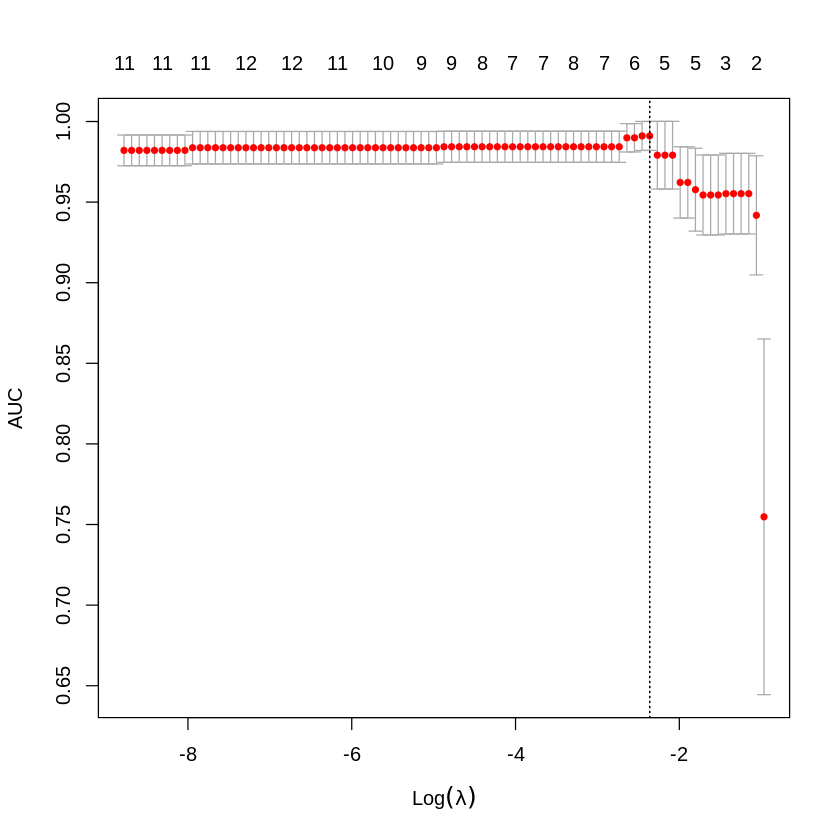

In [26]:
plot(cv.fit)

In [27]:
f1 = glmnet(x, y, family="binomial",type.measure = "auc", nfolds=5)

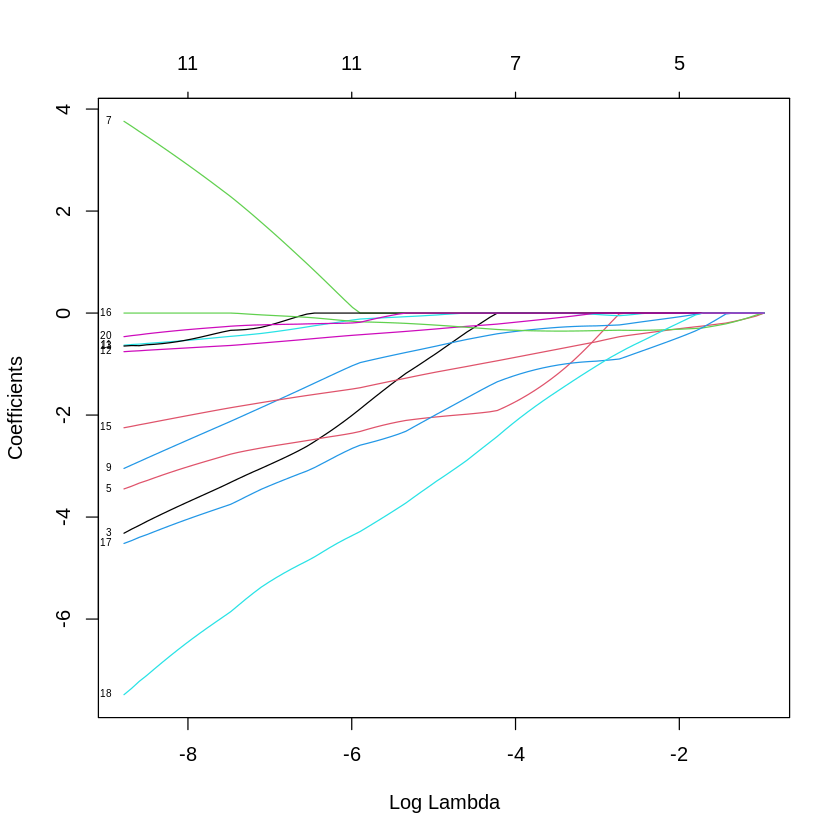

In [28]:
plot(f1, xvar="lambda", label=TRUE)

In [29]:
pdf("cvMM.pdf",width=5,height=5)
plot(cv.fit)
dev.off()
pdf("lamMM.pdf",width=5.5,height=5)
plot(f1, xvar="lambda", label=TRUE)
dev.off()

png 
  2

png 
  2

In [30]:
freq.lasso.results <- as.data.frame(table(lasso.results))
freq.lasso.results<-freq.lasso.results[-1,]

In [31]:
freq.lasso.results

,lasso.results,Freq
,<fct>,<int>
2,ARID1B,53
3,ATP2A1,1
4,ATP2A3,21
5,CHD8,73
6,DTX1,11
7,EP400,7
8,KDM5A,61
9,KDM6A,11
10,KDM6B,42


In [32]:
freq.lasso.results<-freq.lasso.results[which(freq.lasso.results$Freq>70),]

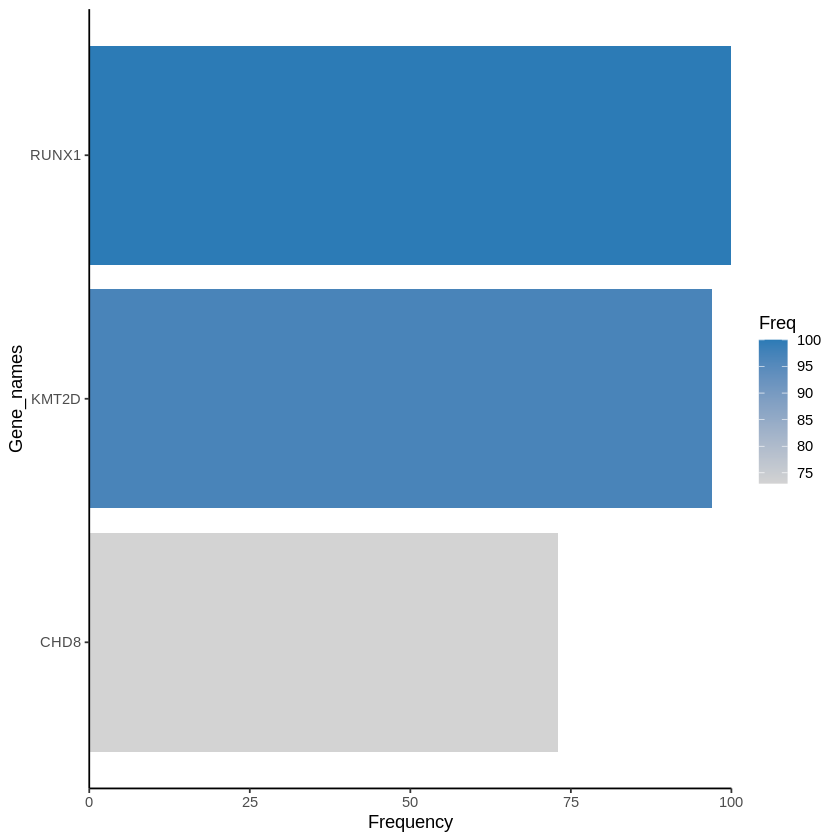

In [33]:
library(ggplot2)
ggplot(freq.lasso.results,aes(x= reorder(lasso.results,Freq), y=Freq,fill=Freq)) +                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
  geom_bar(stat = "identity") +
xlab('Gene_names')+
  coord_flip()+
  scale_fill_gradient(low = "lightgrey", high = brewer.pal(4,'RdYlBu')[4])+
  scale_y_continuous(name="Frequency",expand=c(0,0))+
  theme_classic()

In [34]:
ggsave('lassoMM.pdf',height=3,width=3)

[2]AL

In [35]:
lasso.results <- c()

In [36]:
matrix2<-expr_df2AL

In [37]:
matrix2$Y<-gsub('group1',1,matrix2$Y)
matrix2$Y<-gsub('group2',2,matrix2$Y)

In [38]:
for (j in 1:100) {
  s <- matrix2[sample(1:nrow(matrix2),ceiling(dim(matrix2)[1]*0.8),replace=F),]
  ts <- apply(s,2,as.numeric)
  y <- as.matrix(ts[,21])
  x <- as.matrix(ts[,-21])
  cv.fit <- cv.glmnet(x,y,family="binomial", type.measure = "auc", nfolds=5)
  co<-coef(cv.fit,s="lambda.1se")
  name <- rownames(co)[co[,1]!=0]
  lasso.results <- c(lasso.results, name)
  pred = predict(cv.fit, newx = x, type = 'response',s ="lambda.min")
  roc<-roc(y,pred)
  plot.roc(roc,col="red",print.auc =TRUE,print.auc.col = "darkgreen",auc.polygon = TRUE,auc.polygon.col = "pink")
 dev.off() }

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as response. Unexpected results may be produced, please pass a vector or factor.”
Setting direction: controls < cases

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as response. Unexpected results may be produced, please pass a vector or factor.”
Setting direction: controls < cases

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as res

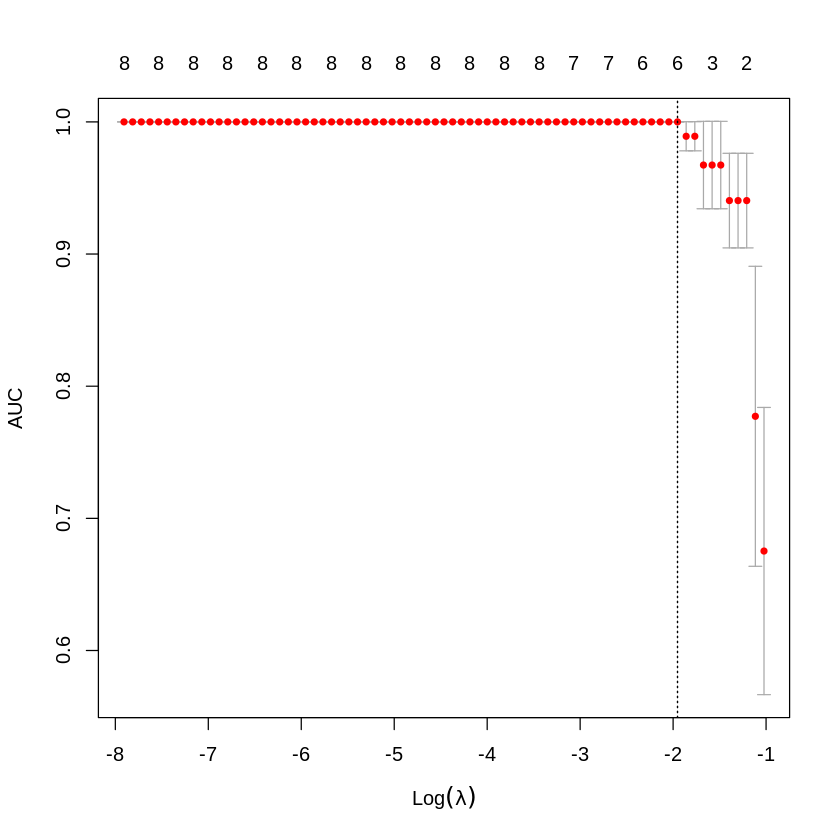

In [39]:
plot(cv.fit)

In [40]:
f1 = glmnet(x, y, family="binomial",type.measure = "auc", nfolds=5)

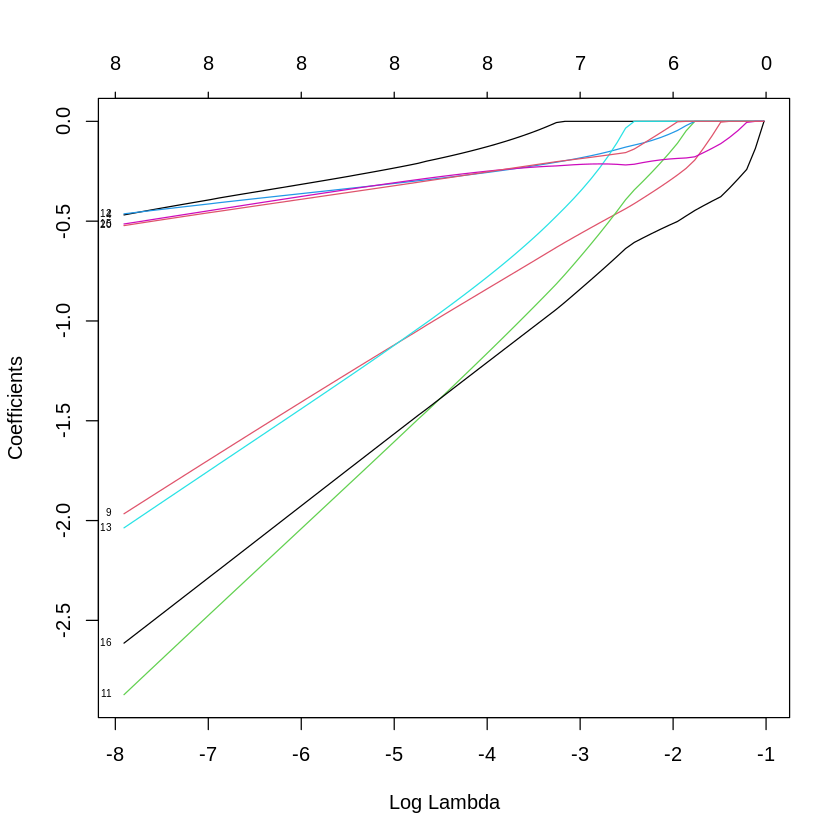

In [41]:
plot(f1, xvar="lambda", label=TRUE)

In [42]:
pdf("cvAL.pdf",width=5,height=5)
plot(cv.fit)
dev.off()
pdf("lamAL.pdf",width=5.5,height=5)
plot(f1, xvar="lambda", label=TRUE)
dev.off()

png 
  2

png 
  2

In [43]:
freq.lasso.results <- as.data.frame(table(lasso.results))
freq.lasso.results<-freq.lasso.results[-1,]

In [44]:
freq.lasso.results

,lasso.results,Freq
,<fct>,<int>
2,ARID1B,1
3,ATP2A1,1
4,CHD8,5
5,DTX1,4
6,EP400,31
7,KDM5A,81
8,KDM6A,1
9,KDM6B,41
10,KMT2B,3


In [45]:
freq.lasso.results<-freq.lasso.results[which(freq.lasso.results$Freq>50),]

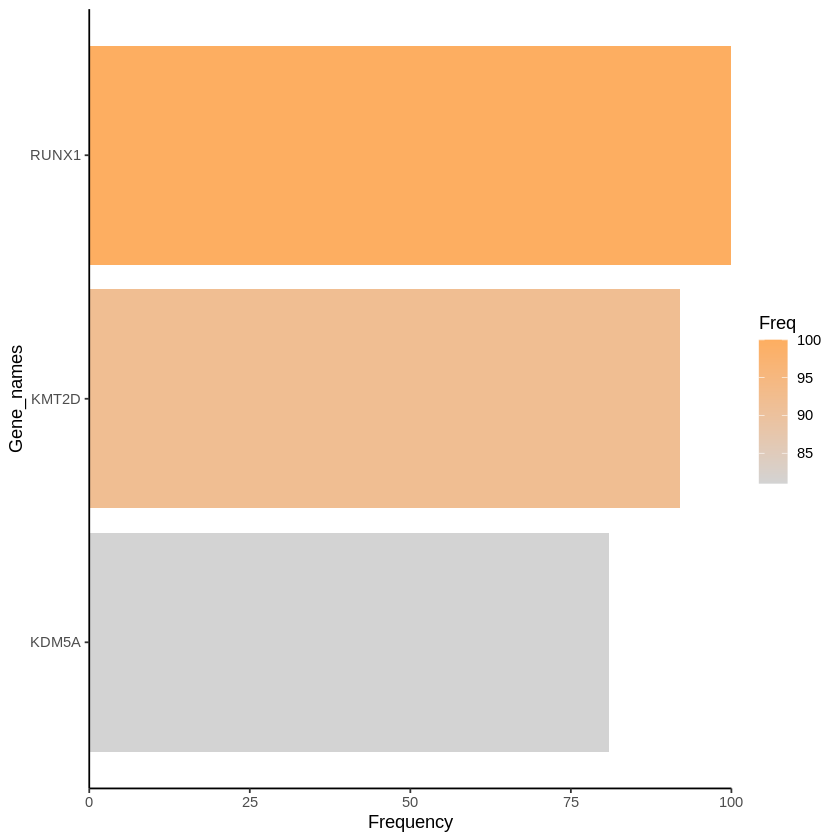

In [46]:
library(ggplot2)
ggplot(freq.lasso.results,aes(x= reorder(lasso.results,Freq), y=Freq,fill=Freq)) +                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
  geom_bar(stat = "identity") +
xlab('Gene_names')+
  coord_flip()+
  scale_fill_gradient(low = "lightgrey", high = brewer.pal(4,'RdYlBu')[2])+
  scale_y_continuous(name="Frequency",expand=c(0,0))+
  theme_classic()

In [47]:
ggsave('lassoAL.pdf',height=3,width=3)

[2]POEMS

In [48]:
lasso.results <- c()

In [49]:
matrix2<-expr_df2POEMS

In [50]:
matrix2$Y<-gsub('group1',1,matrix2$Y)
matrix2$Y<-gsub('group2',2,matrix2$Y)

In [51]:
for (j in 1:100) {
  s <- matrix2[sample(1:nrow(matrix2),ceiling(dim(matrix2)[1]*0.8),replace=F),]
  ts <- apply(s,2,as.numeric)
  y <- as.matrix(ts[,21])
  x <- as.matrix(ts[,-21])
  cv.fit <- cv.glmnet(x,y,family="binomial", type.measure = "auc", nfolds=5)
  co<-coef(cv.fit,s="lambda.1se")
  name <- rownames(co)[co[,1]!=0]
  lasso.results <- c(lasso.results, name)
  pred = predict(cv.fit, newx = x, type = 'response',s ="lambda.min")
  roc<-roc(y,pred)
  plot.roc(roc,col="red",print.auc =TRUE,print.auc.col = "darkgreen",auc.polygon = TRUE,auc.polygon.col = "pink")
 dev.off() }

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as response. Unexpected results may be produced, please pass a vector or factor.”
Setting direction: controls < cases

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as response. Unexpected results may be produced, please pass a vector or factor.”
Setting direction: controls < cases

Setting levels: control = 1, case = 2

Warning message in roc.default(y, pred):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”
Warning message in roc.default(y, pred):
“Deprecated use a matrix as res

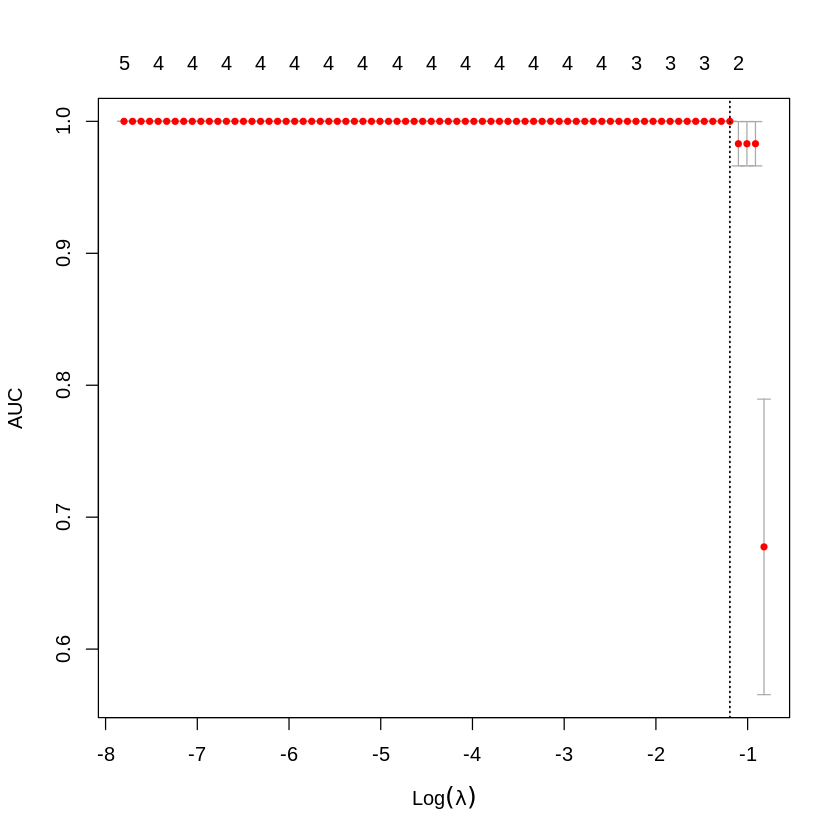

In [52]:
plot(cv.fit)

In [53]:
f1 = glmnet(x, y, family="binomial",type.measure = "auc", nfolds=5)

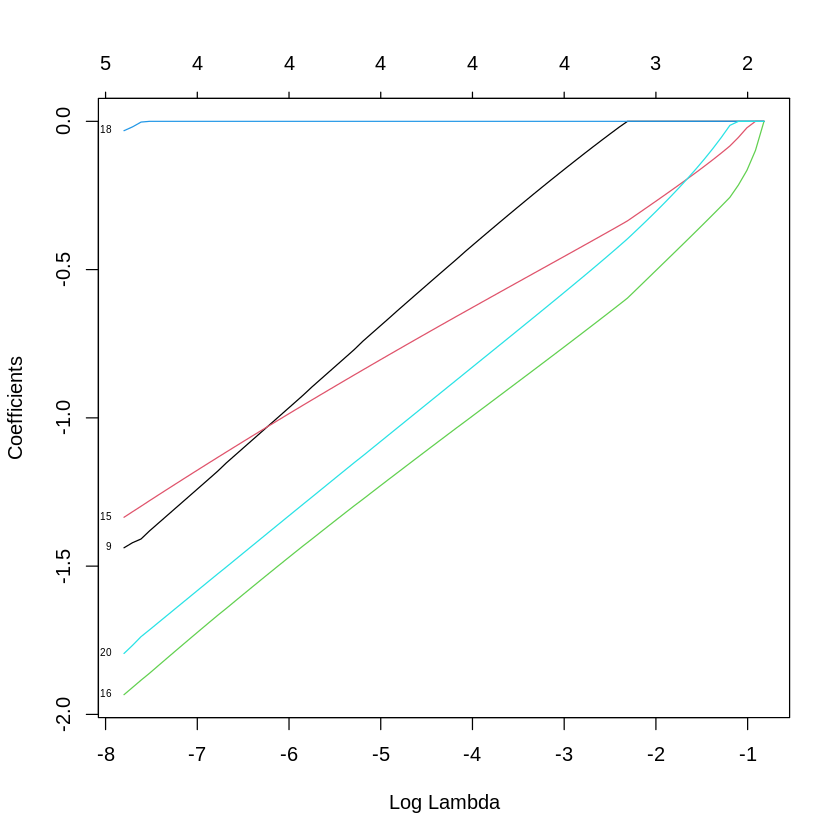

In [54]:
plot(f1, xvar="lambda", label=TRUE)

In [55]:
pdf("cvPOEMS.pdf",width=5,height=5)
plot(cv.fit)
dev.off()
pdf("lamPOEMS.pdf",width=5.5,height=5)
plot(f1, xvar="lambda", label=TRUE)
dev.off()

png 
  2

png 
  2

In [56]:
freq.lasso.results <- as.data.frame(table(lasso.results))
freq.lasso.results<-freq.lasso.results[-1,]

In [57]:
freq.lasso.results

,lasso.results,Freq
,<fct>,<int>
2,EP400,23
3,KDM5A,3
4,KMT2D,75
5,RUNX1,99


In [58]:
freq.lasso.results<-freq.lasso.results[which(freq.lasso.results$Freq>20),]

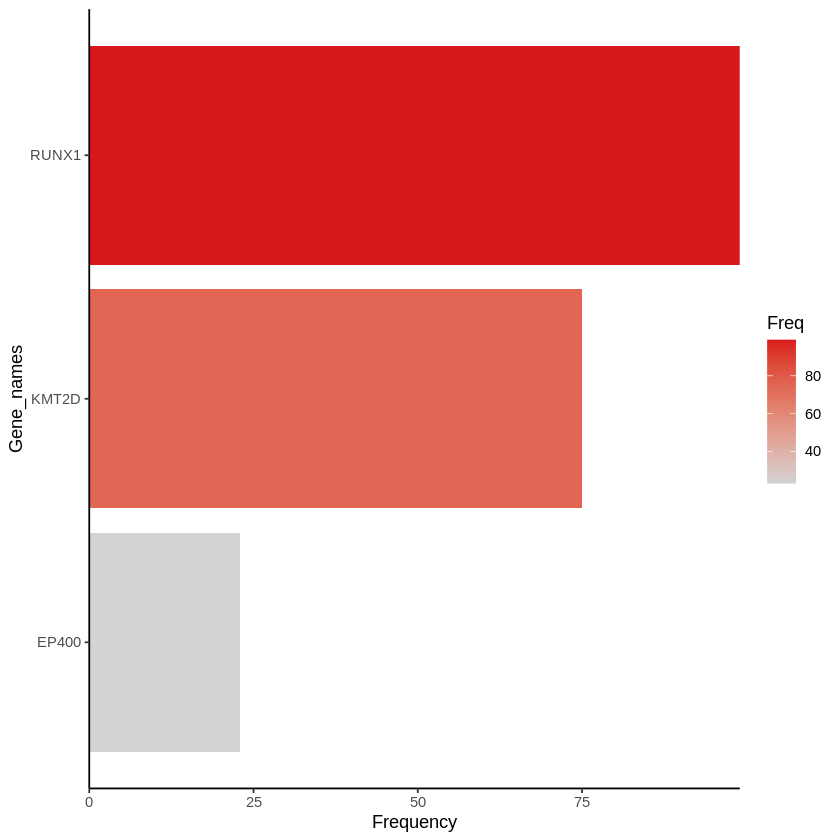

In [59]:
library(ggplot2)
ggplot(freq.lasso.results,aes(x= reorder(lasso.results,Freq), y=Freq,fill=Freq)) +                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
  geom_bar(stat = "identity") +
xlab('Gene_names')+
  coord_flip()+
  scale_fill_gradient(low = "lightgrey", high = brewer.pal(4,'RdYlBu')[1])+
  scale_y_continuous(name="Frequency",expand=c(0,0))+
  theme_classic()

In [60]:
ggsave('lassoPOEMS.pdf',height=3,width=3)